In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
NUM_TRIALS=100000
EPS=.1
BANDIT_PROBABILITIES=[.2,.5,.75]

In [3]:
class Bandit:
    def __init__(self,p):
        self.p=p
        self.p_estimate=0
        self.N=0
        
    def pull(self):
        return np.random.random()<self.p
    
    def update(self,x):
        self.N=self.N+1
        self.p_estimate=((self.p_estimate*(self.N-1))+x)/self.N
    

In [4]:
def ucb(mean,n,nj):
    return mean+ np.sqrt(2*np.log(n)/nj)

In [5]:
def run_expriment():
    bandits=[Bandit(p) for p in BANDIT_PROBABILITIES]
    rewards=np.empty(NUM_TRIALS)
    total_plays=0
    
    #initailization: play each bandit once
    for j in range(len(bandits)):
        x=bandits[j].pull()
        total_plays +=1
        bandits[j].update(x)
      
      
        
    for i in range(NUM_TRIALS):
        j=np.argmax([ucb(b.p_estimate,total_plays,b.N) for b in bandits])
       
        x=bandits[j].pull()
        total_plays +=1
        bandits[j].update(x)
        rewards[i]=x
    cumulative_average = np.cumsum(rewards)/(np.arange(NUM_TRIALS)+1)
    
    for b in bandits:
        print("mean estimate:",b.p_estimate)
    
    print("total reward earned:",rewards.sum())
    print("overall win rate:",rewards.sum()/NUM_TRIALS)
    
    print("num times selected each bandit:",[b.N for b in bandits])
    
    plt.plot(cumulative_average)
    plt.plot(np.ones(NUM_TRIALS)*np.max(BANDIT_PROBABILITIES))
    plt.xscale('log')
    plt.show()
    
    
        

mean estimate: 0.21052631578947367
mean estimate: 0.5014836795252227
mean estimate: 0.7479365398132352
total reward earned: 74671.0
overall win rate: 0.74671
num times selected each bandit: [76, 337, 99590]


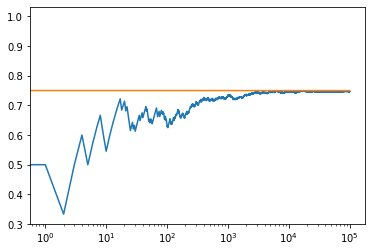

In [6]:
if __name__ =="__main__":
    run_expriment()